In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

/var/folders/81/rb_q3ysn6cn6yl6c4g9w2lp00000gn/T/ipykernel_51025/44414485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Class']==1], x='City', palette='viridis')
/var/folders/81/rb_q3ysn6cn6yl6c4g9w2lp00000gn/T/ipykernel_51025/44414485.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Class']==1], x='Merchant_Category', palette='magma')


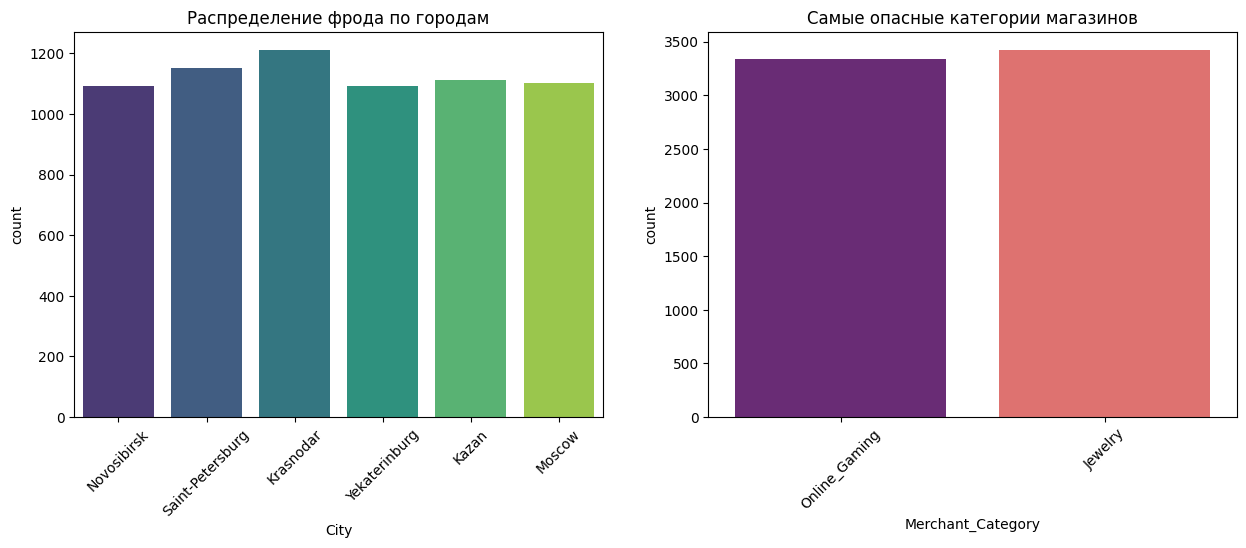

In [25]:
df = pd.read_csv('../data/transactions.csv')

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df[df['Class']==1], x='City', palette='viridis')
plt.title('Распределение фрода по городам')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.countplot(data=df[df['Class']==1], x='Merchant_Category', palette='magma')
plt.title('Самые опасные категории магазинов')
plt.xticks(rotation=45)
plt.show()

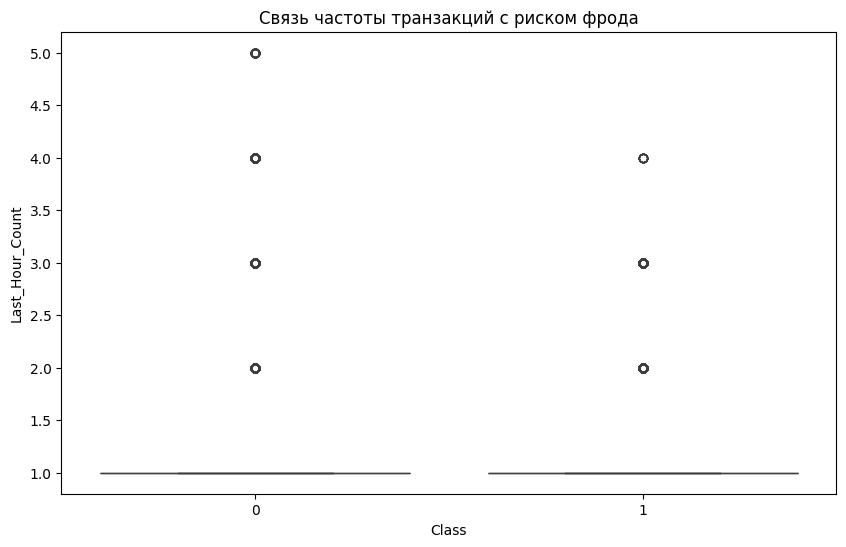

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Last_Hour_Count', data=df)
plt.title('Связь частоты транзакций с риском фрода')
plt.show()

In [29]:
le_city = LabelEncoder()
df['City_Enc'] = le_city.fit_transform(df['City'])

le_cat = LabelEncoder()
df['Cat_Enc'] = le_cat.fit_transform(df['Merchant_Category'])

In [30]:
features = ['Amount', 'Last_Hour_Count', 'City_Enc', 'Cat_Enc', 'V1', 'V2']
X = df[features]
y = df['Class']

In [31]:
joblib.dump(le_city, '../consumer/le_city.pkl')
joblib.dump(le_cat, '../consumer/le_cat.pkl')

['../consumer/le_cat.pkl']

In [32]:
fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0].sample(len(fraud_df)*10)
balanced_df = pd.concat([fraud_df, normal_df])

X_bal = balanced_df[features]
y_bal = balanced_df['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_bal)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_bal, test_size=0.2)

In [34]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [35]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13494
           1       1.00      1.00      1.00      1374

    accuracy                           1.00     14868
   macro avg       1.00      1.00      1.00     14868
weighted avg       1.00      1.00      1.00     14868



In [36]:
joblib.dump(model, '../consumer/model.pkl')
joblib.dump(scaler, '../consumer/scaler.pkl')
print("model & scaler is saved in consumer")

model & scaler is saved in consumer
